### Logistic Regression
- Binary classification (either 0 or 1)
- uses sigmoid function to convert the linear combination of input features into a probability
- y_hat = sigmoid(wx + b)
- Sigmoid function is activation function
- the output of sigmoid function is in the range [0, 1]

In [1]:
import pandas as pd
import numpy as np

In [2]:
data_path = "E:\TECH-AXIS\ClassTech\Class1\data\diabetes.csv"

In [3]:
df = pd.read_csv(data_path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,0,33.6,0.627,50,1
1,1,85,66.0,29,0,26.6,0.351,31,0
2,8,183,64.0,0,0,23.3,0.672,32,1
3,1,89,66.0,23,94,28.1,0.167,21,0
4,0,137,40.0,35,168,43.1,2.288,33,1


In [4]:
df.duplicated().sum()

np.int64(0)

- No duplicate records are present

In [5]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               1
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

- Bloodpressure feature has 1 missing value

In [6]:
bp_median = df['BloodPressure'].median()
bp_median

np.float64(72.0)

In [7]:
df[df['BloodPressure'].isna()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
12,10,139,NaN,0,0,27.1,1.441,57,0


In [8]:
df['BloodPressure'] = np.where(
    df['BloodPressure'].isna(), 
    bp_median, 
    df['BloodPressure']
)
df.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,0,33.6,0.627,50,1
1,1,85,66.0,29,0,26.6,0.351,31,0
2,8,183,64.0,0,0,23.3,0.672,32,1
3,1,89,66.0,23,94,28.1,0.167,21,0
4,0,137,40.0,35,168,43.1,2.288,33,1
5,5,116,74.0,0,0,25.6,0.201,30,0
6,3,78,50.0,32,88,31.0,0.248,26,1
7,10,115,0.0,0,0,35.3,0.134,29,0
8,2,197,70.0,45,543,30.5,0.158,53,1
9,8,125,96.0,0,0,0.0,0.232,54,1


In [9]:
df[df['BloodPressure'].isna()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


### TODO: Outlier Identification and Handling 

In [10]:
q1 = df['BloodPressure'].quantile(0.25)
q3 = df['BloodPressure'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
lower_bound, upper_bound

(np.float64(35.0), np.float64(107.0))

In [11]:
df['is_outlier'] = (df['BloodPressure'] < lower_bound) | (df['BloodPressure'] > upper_bound)
outliers = df[df['is_outlier'] == True]
outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,is_outlier
7,10,115,0.0,0,0,35.3,0.134,29,0,True
15,7,100,0.0,0,0,30.0,0.484,32,1,True
18,1,103,30.0,38,83,43.3,0.183,33,0,True
43,9,171,110.0,24,240,45.4,0.721,54,1,True
49,7,105,0.0,0,0,0.0,0.305,24,0,True
60,2,84,0.0,0,0,0.0,0.304,21,0,True
78,0,131,0.0,0,0,43.2,0.270,26,1,True
81,2,74,0.0,0,0,0.0,0.102,22,0,True
84,5,137,108.0,0,0,48.8,0.227,37,1,True
106,1,96,122.0,0,0,22.4,0.207,27,0,True


In [12]:
df['BloodPressure'] = np.where(df['is_outlier'] == True, bp_median, df['BloodPressure'])
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,is_outlier
0,6,148,72.0,35,0,33.6,0.627,50,1,False
1,1,85,66.0,29,0,26.6,0.351,31,0,False
2,8,183,64.0,0,0,23.3,0.672,32,1,False
3,1,89,66.0,23,94,28.1,0.167,21,0,False
4,0,137,40.0,35,168,43.1,2.288,33,1,False
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180,32.9,0.171,63,0,False
764,2,122,70.0,27,0,36.8,0.340,27,0,False
765,5,121,72.0,23,112,26.2,0.245,30,0,False
766,1,126,60.0,0,0,30.1,0.349,47,1,False


In [13]:
# Independent and dependent feature split
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [14]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =  train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape    

((614, 9), (154, 9), (614,), (154,))

In [ ]:
from sklearn.linear_model import LogisticRegression
# solver liblinear is used for small datasets
lr_clf = LogisticRegression(max_iter=190, solver='liblinear')
lr_clf.fit(X_train, y_train)

d:\anoconda\envs\tech-axis\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=190)

In [17]:
y_pred_sk = lr_clf.predict(X_test)
y_pred_sk

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [18]:
pd.DataFrame({
    'y_test': y_test,
    'y_test_sk': y_pred_sk
}).head(20)

,y_test,y_test_sk
668,0,0
324,0,0
624,0,0
690,0,0
473,0,0
204,0,0
97,0,0
336,0,1
568,0,1
148,0,1


In [19]:
from sklearn.metrics import accuracy_score
# accuracy is a measure of how often the classifier is correct.
# accuracy is calculated as the ratio of the number of correct predictions to the total number of predictions made.
# accuracy = (total number of correct predictions) / (total number of predictions)
accuracy_score(y_test, y_pred_sk) * 100 # *100 for percentage

75.32467532467533

### Confusion matrix

In [20]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_test, y_pred_sk)
mat

array([[79, 20],
       [18, 37]])

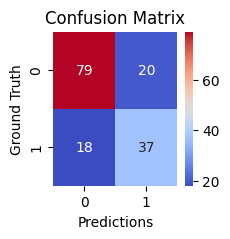

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(2, 2))
sns.heatmap(mat, annot=True, cmap='coolwarm')
plt.ylabel('Ground Truth')
plt.xlabel('Predictions')
plt.title('Confusion Matrix')
plt.show()

# 78 is in class 0 which identifies the number of true negatives (TN)

In [22]:
78 + 21 + 18 + 37

154

In [ ]:
# TP + TN / TP + TN + FP + FN
(78 + 37) / (78 + 21 + 18 + 37) # -> accuracy calculation

0.7467532467532467

In [ ]:
# Precision: among the total predicted values, how many were actually positive 
# Precision = TP / (TP + FP)

# Recall: among the total real actual values, how many were predicted as positive
# Recall = TP / (TP + FN)
# Generally focus on recall when in critical situation or the 
# cost of false negatives is high.
# F1 Score: the harmonic mean of precision and recall, ranges from 0 to 1.
# F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: ", precision_score(y_test, y_pred_sk))
print("Recall: ", recall_score(y_test, y_pred_sk))
print("F1 Score: ", f1_score(y_test, y_pred_sk))

Precision:  0.6491228070175439
Recall:  0.6727272727272727
F1 Score:  0.6607142857142857


In [ ]:
# log loss: the measure of how well the predicted probabilities match the actual outcomes.
# It is a measure of the uncertainty of the predictions.
 

In [ ]:
# Multiclass classification

# softmax function if need to predict 3 or more than 3 class,
# covert to probability distribution

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

DecisionTreeClassifier().fit()